In [6]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "plot_config.py").exists():
            return p
    raise RuntimeError("plot_config.py not found above " + str(start))

try:
    _start = Path(__file__).resolve().parent
except NameError:
    _start = Path.cwd().resolve()

REPO_ROOT = _find_repo_root(_start)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import h5py
import os

import plot_config  # noqa: F401

In [7]:
SUBJECT_ID = "sub-NDARINVTU813PDR"
FILE_SUFFIX = "_task-hammerAP_run-01_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.h5"

# FILE_DIR = Path("/cluster/work/ianpe/masters_thesis/preprocessing/tcp/parcellations") # IDUN
FILE_DIR = Path("/Users/ipeglin/Documents/masters_thesis/preprocessing/tcp/parcellations") # LOCAL
FILE_PATH = FILE_DIR / SUBJECT_ID / f"{SUBJECT_ID}{FILE_SUFFIX}"

ROI_IDX = 2 # lAMY-rh

In [8]:
SAVE_DIR = Path("/Users/ipeglin/LaTeX/masters_thesis/Images/pipeline")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [9]:
# plotting first ROI
ROI_IDX = 0

In [10]:
with h5py.File(FILE_PATH, 'r') as f:
  raw_ts = np.asarray(f['tcp_timeseries_raw'])
  wv_standardized_ts = np.asarray(f['tcp_timeseries_voxelzscore'])
  

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/Users/ipeglin/Documents/masters_thesis/preprocessing/tcp/parcellations/sub-NDARINVTU813PDR/sub-NDARINVTU813PDR_task-hammerAP_run-01_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

/var/folders/_w/yxnxx2rn2t11qwh4kx9h9g680000gn/T/ipykernel_85859/2366979833.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(2, 1, figsize=(15, 12), sharex=True)


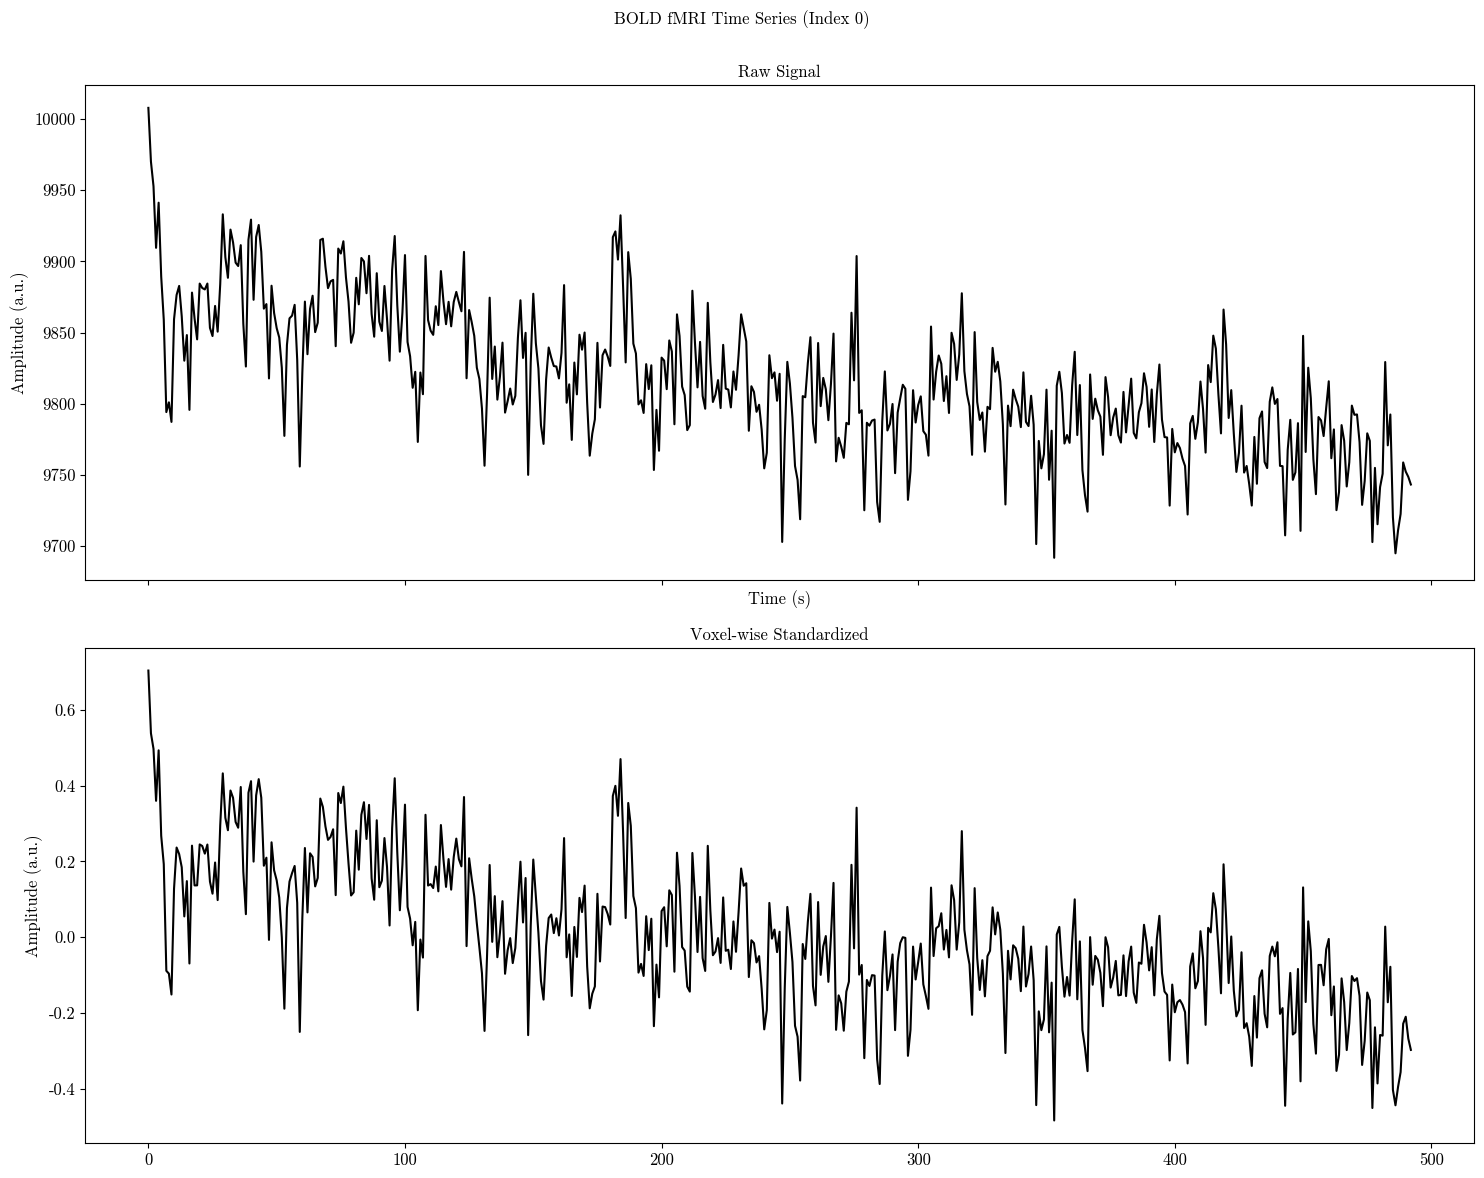

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
ax[0].plot(raw_ts[ROI_IDX], c="k")
ax[0].set_ylabel("Amplitude (a.u.)")
ax[0].set_xlabel("Time (s)")
ax[0].set_title("Raw Signal")
ax[1].plot(wv_standardized_ts[ROI_IDX], c="k")
ax[1].set_ylabel("Amplitude (a.u.)")
ax[1].set_title("Voxel-wise Standardized")

fig.suptitle(f"BOLD fMRI Time Series (Index {ROI_IDX})")
fig.tight_layout(rect=[0, 0, 1, 0.98])

In [ ]:
# plt.savefig(SAVE_DIR / "timeseries_modes.pdf")